<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº4
#### Jeremias Martin Pantozzi


## Introducción


En el análisis espectral práctico mediante la Transformada Discreta de Fourier (DFT), la representación de señales de tiempo continuo en un intervalo finito introduce el fenómeno conocido como **desparramo espectral** (*spectral leakage*). Este fenómeno ocurre cuando las frecuencias de la señal no coinciden exactamente con los centros de los bins de la DFT, provocando que la energía de una componente senoidal se disperse a lo largo de frecuencias adyacentes.

Para mitigar este efecto y mejorar la resolución en amplitud o frecuencia, se recurre a la técnica de **ventaneo** (*windowing*), multiplicando la señal en el dominio del tiempo por una función de ventana $w(n)$ antes del cálculo de la transformada. Cada función de ventana posee un compromiso intrínseco entre el ancho del lóbulo principal (que determina la resolución en frecuencia) y la atenuación de los lóbulos secundarios (que determina la capacidad de detectar componentes de baja amplitud cercanas a picos dominantes).

El objetivo de este trabajo es evaluar el impacto de diferentes topologías de ventanas en la exactitud y precisión de la estimación de la **amplitud** y la **frecuencia** de una señal senoidal contaminada con ruido aditivo, analizando estadísticamente el sesgo ($s_a$) y la varianza ($v_a$) de los estimadores a través de simulaciones.

### 1.1 Modelo de la Señal

Se analiza un proceso estocástico discreto $x(n)$ definido por:

$$x(n) = a_0 \cdot \sin(\Omega_1 \cdot n) + n_a(n)$$

Donde los parámetros y variables del modelo se especifican a continuación:
* **Amplitud nominal:** $a_0 = 2$ (calibrada para una potencia de la señal senoidal pura de $P_{\text{signal}} = 1\text{ W}$).
* **Frecuencia angular de la portadora:** $\Omega_1 = \Omega_0 + f_r \cdot \frac{2\pi}{N}$
* **Frecuencia central:** $\Omega_0 = \frac{\pi}{2}$
* **Desviación de frecuencia ($f_r$):** Variable aleatoria con distribución uniforme que simula el desajuste respecto al centro del bin espectral:
  $$f_r \sim \mathcal{U}(-2, 2)$$
* **Ruido aditivo ($n_a$):** Ruido Blanco Gaussiano Agregado (AWGN) con media cero y varianza dependiente de la relación señal-ruido (SNR) objetivo:
  $$n_a \sim \mathcal{N}(0, \sigma^2)$$

### 1.2 Definición de los Estimadores

Para cada ventana $w_i(n)$ bajo estudio, se obtienen las muestras espectrales mediante la transformada de Fourier de la señal ventaneada:

$$X_i^w(\Omega) = \mathcal{F}\{x(n) \cdot w_i(n)\}$$

A partir de este espectro, se definen los siguientes estimadores de parámetros:

1. **Estimador de Amplitud ($\hat{a}_{i1}$):** Evaluado en la frecuencia central de diseño:
   $$\hat{a}_{i1} = |X_i^w(\Omega_0)|$$

2. **Estimador de Frecuencia ($\hat{\Omega}_{i1}$):** Determinado mediante la búsqueda del argumento que maximiza la magnitud del espectro (pico espectral):
   $$\hat{\Omega}_{i1} = \arg \max_{\Omega} \{|X_i^w(\Omega)|\}$$

### 1.3 Ventanas bajo Análisis

El estudio comparativo se realiza utilizando cuatro configuraciones de ventanas espectrales provistas por la librería `scipy.signal.windows`:
1. **Ventana Rectangular:** Equivalente a no aplicar ventana (máxima resolución espectral, pero alta filtración).
2. **Ventana Flat-top:** Diseñada específicamente para minimizar el error en la estimación de amplitud a expensas de un lóbulo principal ancho.
3. **Ventana Blackman-Harris:** Caracterizada por una excelente atenuación de lóbulos secundarios, óptima para alta dinámica.
4. **Ventana Hamming:** Ventana de tipo coseno alzado modificada para minimizar el primer lóbulo secundario (llegando a unos -43 dB). Ofrece un excelente compromiso práctico, ya que logra una atenuación moderadamente alta manteniendo un lóbulo principal relativamente estrecho en comparación con Blackman o Flat-top.

### 1.4 Protocolo Experimental

Para caracterizar estadísticamente el desempeño frente a la incertidumbre del ruido y el desajuste de frecuencia, se configuran los siguientes parámetros experimentales:
* **Número de muestras por señal:** $N = 1000$ muestras.
* **Número de realizaciones de Monte Carlo:** $M = 200$ ejecuciones independientes por escenario.
* **Escenarios de Relación Señal-Ruido (SNR):** Evaluados de manera paramétrica para $\text{SNR} = 3\text{ dB}$ y $\text{SNR} = 10\text{ dB}$.

Para cada escenario, se calculará el **Sesgo ($s_a$)** y la **Varianza ($v_a$)** de ambos estimadores, volcando los resultados en las tablas comparativas correspondientes.

## Desarrollo Experimental y Resultados: Caso SNR = 10 dB


### Implementación Algorítmica (Python)

A continuación, se presenta el bloque de código encargado de inicializar los vectores, estructurar las señales mediante operaciones matriciales y computar la FFT bajo la calibración de potencia seleccionada.

In [1]:
#%% Librerias
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

n=1000

eps = 1e-12
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1 / fs
    tt = np.arange(0, nn) * ts
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx
def calcular_potencia_db(señal):
    XX = np.fft.fft(señal)
    XXmod = np.abs(XX) / n #Normalizamos 
    # Multiplicamos por 2 para sumar la energía de la frecuencia negativa
    potencia_lineal = (XXmod**2) * 2 
    return 10 * np.log10(potencia_lineal + eps)

#%% GENERO MI SEÑAL x(n)

a0=2
P_sin = (a0**2) / 2
fs=n
delf=fs/n
rea=200

# Calibración del ruido Gaussiano basado en la potencia real de la señal
# SNR = 10 * log10(P_sin / P_ruido) -> P_ruido = P_sin / 10^(SNR/10)
SNR=10
Pr = P_sin / (10**(SNR / 10))
R= np.random.normal(0, np.sqrt(Pr), n)

fr = np.random.uniform(-2, 2, rea)

#Con cuidado pasar omega a frec.... pi/2=n/4 2pi/n=1 y deltaf=fs/n
#w1= n/4 + fr*((2*np.pi)/n)
w1= (n/4 + fr)*delf

arr_w1=w1.reshape(rea,1)
nn=np.arange(0,n)
arr_n=nn.reshape(1,n)

# matriz_w1=np.tile(arr_w1,(1, n))
# matriz_n=np.tile(arr_n, (rea, 1))

# f=(matriz_w1)*(matriz_n)

f=arr_w1*arr_n*1/fs
s=a0*np.sin(2*np.pi*f)


x=s+R


#%% FFTS



#Amplitud a1 ventana rectangular
half_n = n // 2

x_ven=x
a1=np.fft.fft(x_ven,axis=1)* (1.0 / (n * np.sqrt(2))) #escalamos con 1/n para ver W, sqrt(2) es la correccion para que sea 1W ya que a0=2


a1_half = a1[:,:half_n]
# Multiplicamos por 2 para recuperar la amplitud de la sinusoide
# (porque la FFT reparte la energía en frecuencias + y -)
a1mod= np.abs(a1_half)**2
a1pot=a1mod*2

a1mod_dB = 10 * np.log10(a1pot+eps)

### Visualización y Análisis del Comportamiento Gráfico
Antes de extraer las métricas numéricas, la ejecución del código genera dos herramientas visuales críticas para interpretar el fenómeno físico:

**Espectro de Amplitud en dB (Figura 2):** Al graficar el "baleo" o superposición de las 200 realizaciones (líneas grises de fondo para la ventana rectangular) y resaltar una realización en particular, se evidencia el **efecto empalizada** (*picket-fence effect*). Como la frecuencia real de la señal oscila en cada realización debido a $f_r$, el pico del espectro "baila" hacia la izquierda y la derecha del bin 250, sufriendo atenuaciones severas en las pendientes de las ventanas agudas.

In [1]:

#%% Graficar

# --- Figura 1: Señal en el tiempo ---
indice_a_graficar = 0 
seno_seleccionado = x[indice_a_graficar, :]

plt.figure(1, figsize=(10, 4))
plt.plot(nn, seno_seleccionado)
plt.title(f"Señal Temporal (Realización {indice_a_graficar}) - SNR: {SNR} dB")
plt.xlabel("Muestras (n)")
plt.ylabel("Amplitud")
plt.grid(True, alpha=0.3)
plt.show()

# --- Figura 2: Espectro en dB ---
plt.figure(2, figsize=(10, 4))
# Graficamos el espectro de todas las realizaciones para ver cómo "baila" el pico
plt.plot(a1mod_dB.T, alpha=0.1, color='gray') 
plt.plot(a1mod_dB[0, :], color='blue', label='Una realización') # Resaltamos una
plt.title("Espectro de Amplitud (dB)")
plt.xlabel("Bins de Frecuencia")
plt.ylabel("Potencia [dB]")
plt.xlim(200, 300) # Hacemos zoom alrededor del bin 250
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


NameError: name 'x' is not defined

## Desarrollo Experimental y Resultados: Caso SNR = 10 dB

En esta sección se exponen y analizan los resultados obtenidos a partir de las 200 realizaciones, configurando una relación señal-ruido (SNR) de 10 dB. Bajo este escenario, la potencia del ruido blanco gaussiano es moderada en comparación con la potencia unitaria calibrada para la senoidal ($1\text{ W}$), lo que permite aislar con mayor claridad el efecto del desajuste de frecuencia ($f_r$) sobre cada topología de ventana.

In [3]:
#%% ESTIMADORES
# Valor real de la amplitud de la senoidal calibrada
valor_teorico = 1.0
f0 = 250 

# Diccionarios para ir guardando los resultados de cada ventana
datos_amplitud = {}
datos_frecuencia = {}

# Listas para guardar las realizaciones crudas (útil para tus histogramas)
estimadores_ventanas = []
estimadores_frec = []

#PROCESAMIENTO DE LA VENTANA RECTANGULAR
indices_max_rect = np.argmax(np.abs(a1[:, :half_n]), axis=1)
estimador_a1 = np.abs(a1[:, 250]) * 2
estimador_f1 = indices_max_rect 

# Guardamos en las listas generales
estimadores_ventanas.append(estimador_a1)
estimadores_frec.append(estimador_f1)

# Estadísticas Rectangular
datos_amplitud["Rectangular"] = {
    "sa": np.mean(estimador_a1) - valor_teorico,
    "va": np.var(estimador_a1)
}
datos_frecuencia["Rectangular"] = {
    "sa": np.mean(estimador_f1) - f0,
    "va": np.var(estimador_f1)
}


#PROCESAMIENTO DE LAS OTRAS VENTANAS
w_flat = sig.windows.flattop(n)
w_blackmanharris = sig.windows.blackmanharris(n)
w_hamming = sig.windows.hamming(n)

ventanas = [w_flat, w_blackmanharris, w_hamming]
nombres = ["Flat-top", "Blackman-Harris", "Hamming"]

for v_actual, nombre in zip(ventanas, nombres):
    # Aplicar ventana y FFT calibrada
    x_ven = x * v_actual 
    a_fft = np.fft.fft(x_ven, axis=1) * (1.0 / (n * np.sqrt(2)))

    # Estimadores (*2 por mitad de FFT)
    est_a = np.abs(a_fft[:, 250]) * 2
    indices_max_v = np.argmax(np.abs(a_fft[:, :half_n]), axis=1)
    est_f = indices_max_v 

    # Guardar vectores crudos para los gráficos
    estimadores_ventanas.append(est_a)
    estimadores_frec.append(est_f)

    # Estadísticas Ventana Actual
    datos_amplitud[nombre] = {
        "sa": np.mean(est_a) - valor_teorico,
        "va": np.var(est_a)
    }
    datos_frecuencia[nombre] = {
        "sa": np.mean(est_f) - f0,
        "va": np.var(est_f)
    }


#IMPRESIÓN DE LAS TABLAS
print(f"\n======================================================================")
print(f"                 RESULTADOS DE SIMULACIÓN PARA SNR = {SNR} dB")
print(f"======================================================================")

print("\n--- CUADRO COMPARATIVO: ESTIMACIÓN DE AMPLITUD ---")
print(f"{'Ventana Espectral':<20} | {'Valor Medio':<14} | {'Sesgo (sa)':<14} | {'Varianza (va)':<14}")
print("-" * 72)
for ventana, metrices in datos_amplitud.items():
    # Recuperamos la media exacta calculada previamente en el bucle
    media_a = metrices['sa'] + valor_teorico
    print(f"{ventana:<20} | {media_a:<14.6f} | {metrices['sa']:<14.6f} | {metrices['va']:<14.6f}")

print("\n--- CUADRO COMPARATIVO: ESTIMACIÓN DE FRECUENCIA ---")
print(f"{'Ventana Espectral':<20} | {'Valor Medio [Hz]':<16} | {'Sesgo (sf)':<14} | {'Varianza (vf)':<14}")
print("-" * 72)
for ventana, metrices in datos_frecuencia.items():
    # Recuperamos la media en Hz calculada previamente en el bucle
    media_f_val = metrices['sa'] + f0
    print(f"{ventana:<20} | {media_f_val:<16.4f} | {metrices['sa']:<14.4f} | {metrices['va']:<14.6f}")

#VARIABLES FINALES PARA LOS GRÁFICOS
todos_los_estimadores = estimadores_ventanas
todos_est_frec = estimadores_frec
nombres_plot = ["Rectangular", "Flat-top", "Blackman-Harris", "Hamming"]


                 RESULTADOS DE SIMULACIÓN PARA SNR = 10 dB

--- CUADRO COMPARATIVO: ESTIMACIÓN DE AMPLITUD ---
Ventana Espectral    | Valor Medio    | Sesgo (sa)     | Varianza (va) 
------------------------------------------------------------------------
Rectangular          | 0.548933       | -0.451067      | 0.195331      
Flat-top             | 0.280983       | -0.719017      | 0.000976      
Blackman-Harris      | 0.345297       | -0.654703      | 0.017483      
Hamming              | 0.385288       | -0.614712      | 0.069994      

--- CUADRO COMPARATIVO: ESTIMACIÓN DE FRECUENCIA ---
Ventana Espectral    | Valor Medio [Hz] | Sesgo (sf)     | Varianza (vf) 
------------------------------------------------------------------------
Rectangular          | 250.0050         | 0.0050         | 1.424975      
Flat-top             | 249.9950         | -0.0050        | 1.504975      
Blackman-Harris      | 250.0050         | 0.0050         | 1.424975      
Hamming              | 250.0050 

### Histograma comparativo 
Al contrastar los valores estadísticos obtenidos en la simulación con la distribución geométrica de los histogramas, se pueden validar de forma cuantitativa las propiedades de cada ventana bajo un entorno de SNR = 10 dB:


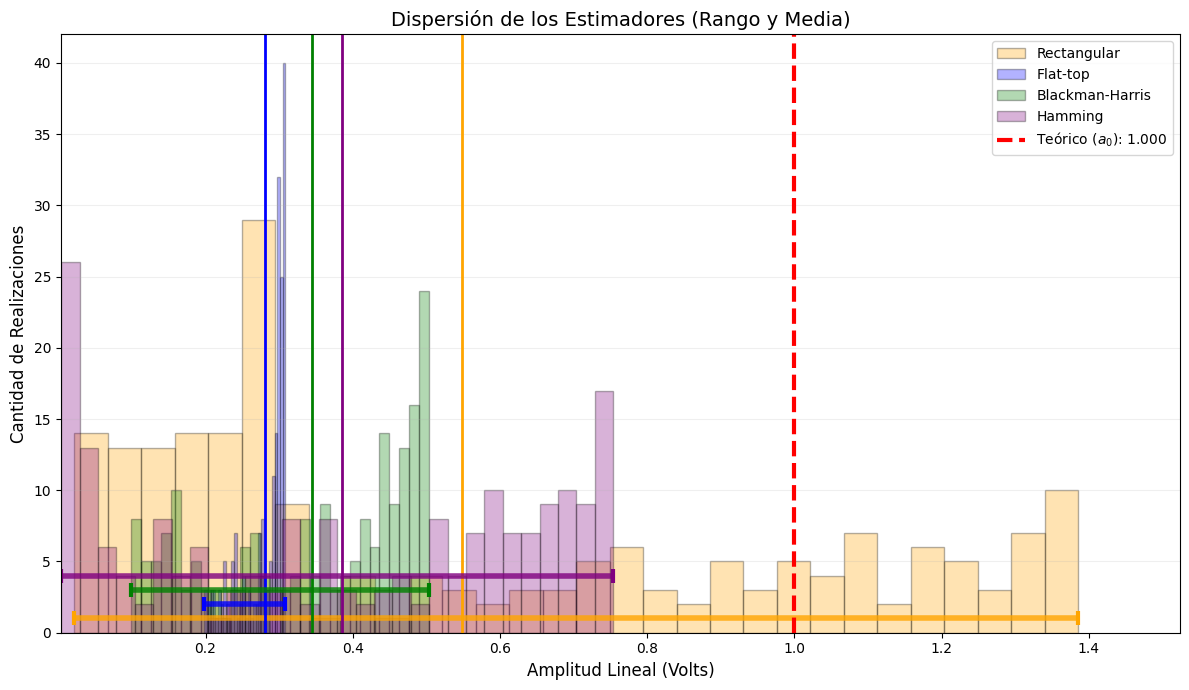

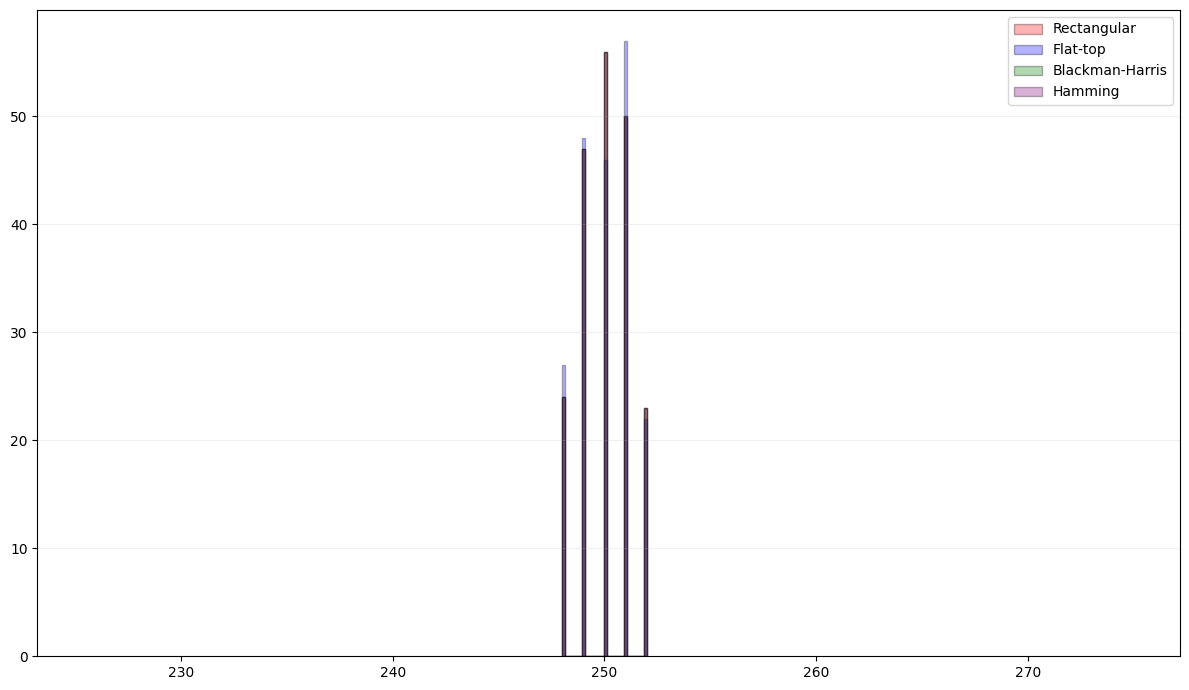

In [4]:
#%% Figura 3: Grafico Comparativo de Histogramas Amplitud

plt.figure(3, figsize=(12, 7))
colores = ['orange', 'blue', 'green', 'purple']

# Altura para las líneas de rango (para que no se encimen en el piso)
alturas_lineas = [1, 2, 3, 4] 

for est, nombre, color, h in zip(todos_los_estimadores, nombres_plot, colores, alturas_lineas):
    # 1. Graficar histograma
    plt.hist(est, bins=30, alpha=0.3, label=nombre, color=color, edgecolor='black')
    
    # 2. Calcular límites del histograma actual
    min_val = np.min(est)
    max_val = np.max(est)
    media_val = np.mean(est)

    # 3. Dibujar línea de la Media
    plt.axvline(media_val, color=color, linestyle='-', linewidth=2)

    # 4. Dibujar línea de Rango (donde arranca y termina el histograma)
    # Ponemos la línea un poquito arriba del cero (h) para que se distingan entre sí
    plt.hlines(y=h, xmin=min_val, xmax=max_val, color=color, linewidth=4, alpha=0.8)
    
    # Marcadores en las puntas (opcional, para que quede más claro)
    plt.plot(min_val, h, '|', color=color, markersize=10, markeredgewidth=3)
    plt.plot(max_val, h, '|', color=color, markersize=10, markeredgewidth=3)

# Línea del Valor Teórico
plt.axvline(valor_teorico, color='red', linestyle='--', linewidth=3, 
            label=f'Teórico ($a_0$): {valor_teorico:.3f}')

plt.title('Dispersión de los Estimadores (Rango y Media)', fontsize=14)
plt.xlabel('Amplitud Lineal (Volts)', fontsize=12)
plt.ylabel('Cantidad de Realizaciones', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.2)

# Ajuste automático del eje X
plt.xlim(np.min(todos_los_estimadores)*0.9, np.max(todos_los_estimadores)*1.1)

plt.tight_layout()
plt.show()

#%% Figura 4: Grafico Comparativo de Histogramas frecuencia

plt.figure(4, figsize=(12, 7))
colores = ['red', 'blue', 'green', 'purple']

# Altura para las líneas de rango (para que no se encimen en el piso)
alturas_lineas = [1, 2, 3, 4] 

for est, nombre, color, h in zip(todos_est_frec, nombres_plot, colores, alturas_lineas):
    # 1. Graficar histograma
    plt.hist(est, bins=30, alpha=0.3, label=nombre, color=color, edgecolor='black')
    

plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.2)

# Ajuste automático del eje X
plt.xlim(np.min(todos_est_frec)*0.9, np.max(todos_est_frec)*1.1)

plt.tight_layout()
plt.show()

#### Análisis de la Ventana Flat-top
* **Evidencia Numérica:** Presenta el mayor sesgo negativo de la simulación ($s_a = -0.719017$, con un Valor Medio de $0.280983$), pero una varianza extraordinariamente baja ($v_a = 0.000976$).
* **Reflejo en el Histograma:** Se observa como una campana azul sumamente esbelta, alta y compacta, concentrada firmemente alrededor del valor $0.28$ (la barra azul de rango en la base del gráfico es la más acotada de todas).
* **Interpretación Física:** Esto demuestra de forma empírica el propósito de diseño de esta topología. Al no estar corregida en el script por su Ganancia Coherente ($CG$), la ventana atenúa sistemáticamente la amplitud lineal en el tiempo (desplazando la media a la izquierda). Sin embargo, su varianza tiende a cero. Esto significa que **independientemente de cuánto "baile" la frecuencia de la señal por culpa del desajuste $f_r$, la ventana Flat-top mide siempre exactamente lo mismo**, eliminando la incertidumbre del efecto empalizada.

#### Análisis de la Ventana Rectangular
* **Evidencia Numérica:** Exhibe el "mejor" valor medio ($0.548933$) y el sesgo menos negativo ($-0.451067$), pero sufre la peor varianza por amplio margen ($v_a = 0.195331$).
* **Reflejo en el Histograma:** Se manifiesta como una distribución amarilla totalmente desparramada y chata que abarca un rango enorme (desde valores cercanos a $0.0$ hasta $1.4$ V). La barra amarilla inferior de rango cubre la totalidad del eje horizontal.
* **Interpretación Física:** Al ser el lóbulo principal de la ventana rectangular extremadamente agudo, el estimador se vuelve una "lotería": si en una realización la frecuencia real coincide cerca del centro del bin 250, registrará una amplitud alta (cercana a $1.4$ V); pero si se desplaza sutilmente hacia los bines contiguos debido a $f_r$, la energía cae en picada hacia cero. Esta extrema sensibilidad al desajuste explica su enorme dispersión y la invalida para mediciones de amplitud en bines fijos.

#### Ventanas Hamming y Blackman-Harris
* **Evidencia Numérica:** Se posicionan en una franja intermedia. Sus valores medios se ubican en $0.385288$ y $0.345297$ respectivamente, con varianzas controladas ($v_a = 0.069994$ y $v_a = 0.017483$).
* **Reflejo en el Histograma:** Sus respectivas campanas (morada y verde) se ubican físicamente entre la Flat-top y el grueso de la Rectangular. Sus barras de rango inferior son notablemente más anchas que las de la Flat-top, pero infinitamente más acotadas que el caos de la Rectangular.
* **Interpretación Física:** Reflejan el comportamiento típico de las ventanas de coseno alzado. Logran suavizar el impacto del desajuste de frecuencia mucho mejor que la rectangular (reduciendo la varianza a una fracción), pero sin llegar al nivel de inmunidad total frente al *picket-fence effect* que ofrece la Flat-top.

#### Estimación de Frecuencia 
* **Evidencia Numérica:** El sesgo es prácticamente nulo en todas las ventanas ($\pm 0.0050$ Hz) y las varianzas de pico son bajas y casi idénticas (oscilando estrechamente entre $1.4249$ y $1.5049$ Hz²).
* **Reflejo en el Histograma:** Se observa como columnas muy delgadas, perfectamente apiladas en los bines enteros inmediatamente vecinos al centro teórico (249, 250 y 251 Hz).


## Desarrollo Experimental y Resultados: Caso SNR = 3dB
En esta sección se exponen y analizan los resultados obtenidos a partir de las 200 realizaciones, configurando una relación señal-ruido (SNR) de 3 dB. Bajo este escenario, la potencia del ruido blanco gaussiano es moderada en comparación con la potencia unitaria calibrada para la senoidal ($1\text{ W}$), lo que permite aislar con mayor claridad el efecto del desajuste de frecuencia ($f_r$) sobre cada topología de ventana.

In [5]:
#%% GENERO MI SEÑAL x(n)

a0=2
P_sin = (a0**2) / 2
fs=n
delf=fs/n
rea=200

# Calibración del ruido Gaussiano basado en la potencia real de la señal
# SNR = 10 * log10(P_sin / P_ruido) -> P_ruido = P_sin / 10^(SNR/10)
SNR=3
Pr = P_sin / (10**(SNR / 10))
R= np.random.normal(0, np.sqrt(Pr), n)

fr = np.random.uniform(-2, 2, rea)

#Con cuidado pasar omega a frec.... pi/2=n/4 2pi/n=1 y deltaf=fs/n
#w1= n/4 + fr*((2*np.pi)/n)
w1= (n/4 + fr)*delf

arr_w1=w1.reshape(rea,1)
nn=np.arange(0,n)
arr_n=nn.reshape(1,n)

# matriz_w1=np.tile(arr_w1,(1, n))
# matriz_n=np.tile(arr_n, (rea, 1))

# f=(matriz_w1)*(matriz_n)

f=arr_w1*arr_n*1/fs
s=a0*np.sin(2*np.pi*f)


x=s+R


#%% FFTS



#Amplitud a1 ventana rectangular
half_n = n // 2

x_ven=x
a1=np.fft.fft(x_ven,axis=1)* (1.0 / (n * np.sqrt(2))) #escalamos con 1/n para ver W, sqrt(2) es la correccion para que sea 1W ya que a0=2


a1_half = a1[:,:half_n]
# Multiplicamos por 2 para recuperar la amplitud de la sinusoide
# (porque la FFT reparte la energía en frecuencias + y -)
a1mod= np.abs(a1_half)**2
a1pot=a1mod*2

a1mod_dB = 10 * np.log10(a1pot+eps)






#%% ESTIMADORES
# Valor real de la amplitud de la senoidal calibrada
valor_teorico = 1.0
f0 = 250 

# Diccionarios para ir guardando los resultados de cada ventana
datos_amplitud = {}
datos_frecuencia = {}

# Listas para guardar las realizaciones crudas (útil para tus histogramas)
estimadores_ventanas = []
estimadores_frec = []

#PROCESAMIENTO DE LA VENTANA RECTANGULAR
indices_max_rect = np.argmax(np.abs(a1[:, :half_n]), axis=1)
estimador_a1 = np.abs(a1[:, 250]) * 2
estimador_f1 = indices_max_rect 

# Guardamos en las listas generales
estimadores_ventanas.append(estimador_a1)
estimadores_frec.append(estimador_f1)

# Estadísticas Rectangular
datos_amplitud["Rectangular"] = {
    "sa": np.mean(estimador_a1) - valor_teorico,
    "va": np.var(estimador_a1)
}
datos_frecuencia["Rectangular"] = {
    "sa": np.mean(estimador_f1) - f0,
    "va": np.var(estimador_f1)
}


#PROCESAMIENTO DE LAS OTRAS VENTANAS
w_flat = sig.windows.flattop(n)
w_blackmanharris = sig.windows.blackmanharris(n)
w_hamming = sig.windows.hamming(n)

ventanas = [w_flat, w_blackmanharris, w_hamming]
nombres = ["Flat-top", "Blackman-Harris", "Hamming"]

for v_actual, nombre in zip(ventanas, nombres):
    # Aplicar ventana y FFT calibrada
    x_ven = x * v_actual 
    a_fft = np.fft.fft(x_ven, axis=1) * (1.0 / (n * np.sqrt(2)))

    # Estimadores (*2 por mitad de FFT)
    est_a = np.abs(a_fft[:, 250]) * 2
    indices_max_v = np.argmax(np.abs(a_fft[:, :half_n]), axis=1)
    est_f = indices_max_v 

    # Guardar vectores crudos para los gráficos
    estimadores_ventanas.append(est_a)
    estimadores_frec.append(est_f)

    # Estadísticas Ventana Actual
    datos_amplitud[nombre] = {
        "sa": np.mean(est_a) - valor_teorico,
        "va": np.var(est_a)
    }
    datos_frecuencia[nombre] = {
        "sa": np.mean(est_f) - f0,
        "va": np.var(est_f)
    }


#IMPRESIÓN DE LAS TABLAS
print(f"\n======================================================================")
print(f"                 RESULTADOS DE SIMULACIÓN PARA SNR = {SNR} dB")
print(f"======================================================================")

print("\n--- CUADRO COMPARATIVO: ESTIMACIÓN DE AMPLITUD ---")
print(f"{'Ventana Espectral':<20} | {'Valor Medio':<14} | {'Sesgo (sa)':<14} | {'Varianza (va)':<14}")
print("-" * 72)
for ventana, metrices in datos_amplitud.items():
    # Recuperamos la media exacta calculada previamente en el bucle
    media_a = metrices['sa'] + valor_teorico
    print(f"{ventana:<20} | {media_a:<14.6f} | {metrices['sa']:<14.6f} | {metrices['va']:<14.6f}")

print("\n--- CUADRO COMPARATIVO: ESTIMACIÓN DE FRECUENCIA ---")
print(f"{'Ventana Espectral':<20} | {'Valor Medio [Hz]':<16} | {'Sesgo (sf)':<14} | {'Varianza (vf)':<14}")
print("-" * 72)
for ventana, metrices in datos_frecuencia.items():
    # Recuperamos la media en Hz calculada previamente en el bucle
    media_f_val = metrices['sa'] + f0
    print(f"{ventana:<20} | {media_f_val:<16.4f} | {metrices['sa']:<14.4f} | {metrices['va']:<14.6f}")

#VARIABLES FINALES PARA LOS GRÁFICOS
todos_los_estimadores = estimadores_ventanas
todos_est_frec = estimadores_frec
nombres_plot = ["Rectangular", "Flat-top", "Blackman-Harris", "Hamming"]


                 RESULTADOS DE SIMULACIÓN PARA SNR = 3 dB

--- CUADRO COMPARATIVO: ESTIMACIÓN DE AMPLITUD ---
Ventana Espectral    | Valor Medio    | Sesgo (sa)     | Varianza (va) 
------------------------------------------------------------------------
Rectangular          | 0.544402       | -0.455598      | 0.191104      
Flat-top             | 0.281991       | -0.718009      | 0.001530      
Blackman-Harris      | 0.342640       | -0.657360      | 0.018362      
Hamming              | 0.384186       | -0.615814      | 0.066446      

--- CUADRO COMPARATIVO: ESTIMACIÓN DE FRECUENCIA ---
Ventana Espectral    | Valor Medio [Hz] | Sesgo (sf)     | Varianza (vf) 
------------------------------------------------------------------------
Rectangular          | 250.0200         | 0.0200         | 1.459600      
Flat-top             | 249.9750         | -0.0250        | 1.484375      
Blackman-Harris      | 250.0150         | 0.0150         | 1.444775      
Hamming              | 250.0200  

### Histograma comparativo 
Al contrastar los valores estadísticos obtenidos en la simulación con la distribución geométrica de los histogramas, se pueden validar de forma cuantitativa las propiedades de cada ventana bajo un entorno de SNR = 3 dB:

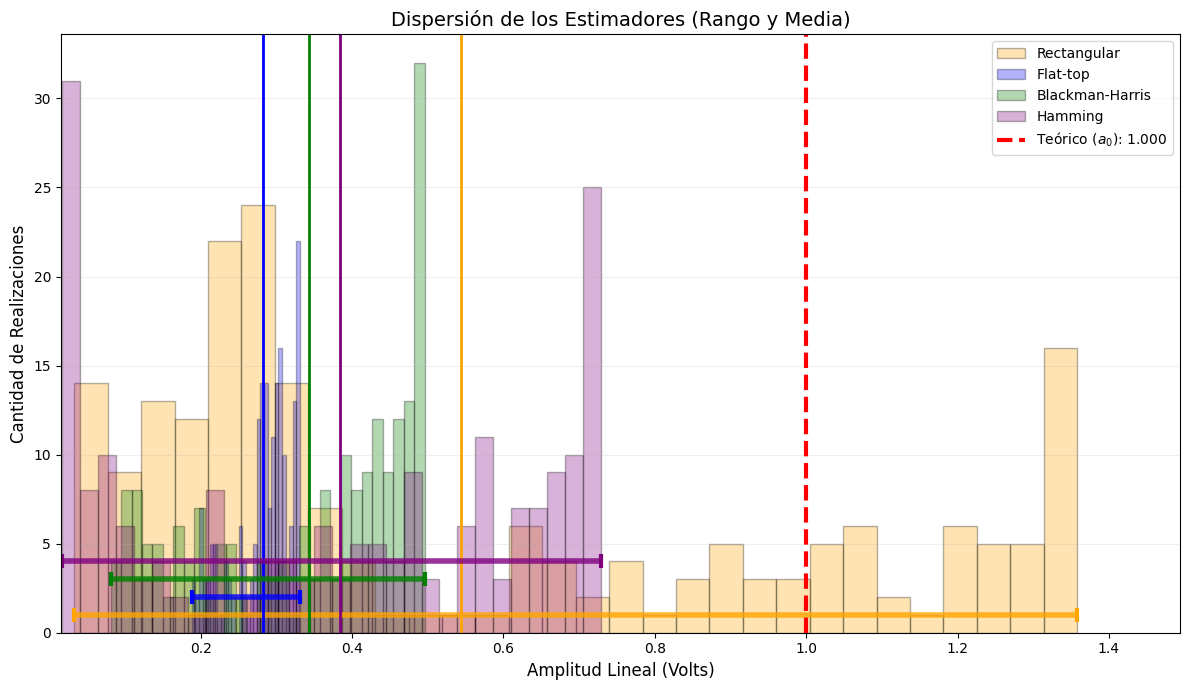

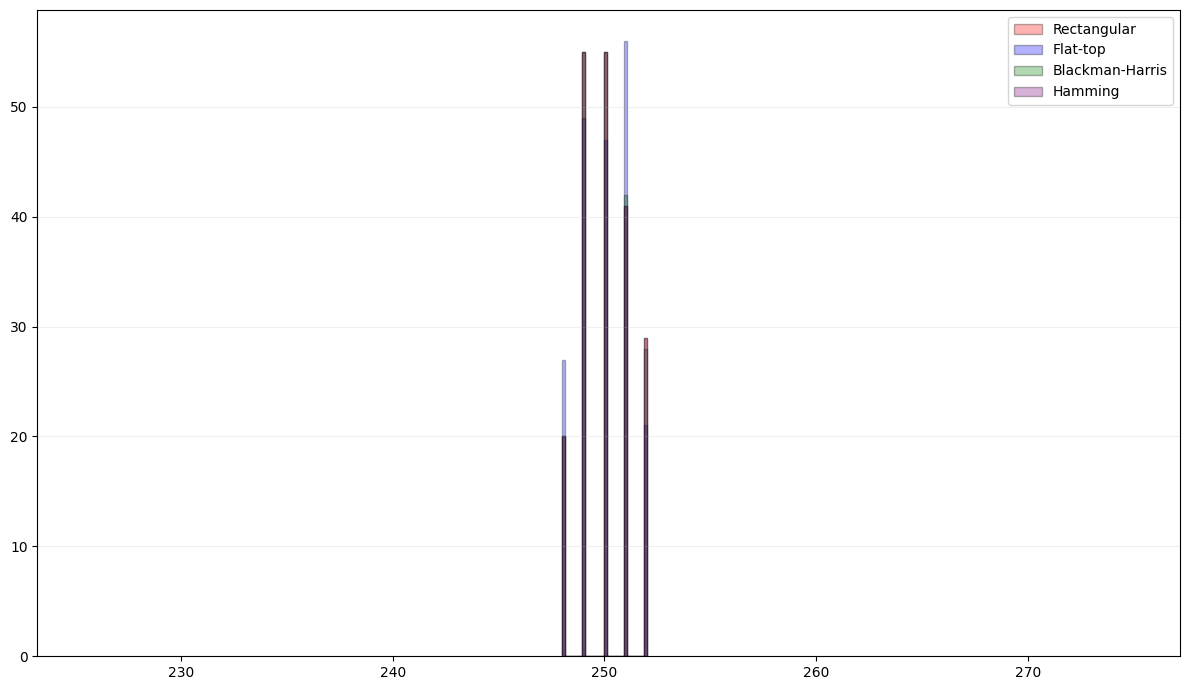

In [6]:
#%% Figura 3: Grafico Comparativo de Histogramas Amplitud

plt.figure(3, figsize=(12, 7))
colores = ['orange', 'blue', 'green', 'purple']

# Altura para las líneas de rango (para que no se encimen en el piso)
alturas_lineas = [1, 2, 3, 4] 

for est, nombre, color, h in zip(todos_los_estimadores, nombres_plot, colores, alturas_lineas):
    # 1. Graficar histograma
    plt.hist(est, bins=30, alpha=0.3, label=nombre, color=color, edgecolor='black')
    
    # 2. Calcular límites del histograma actual
    min_val = np.min(est)
    max_val = np.max(est)
    media_val = np.mean(est)

    # 3. Dibujar línea de la Media
    plt.axvline(media_val, color=color, linestyle='-', linewidth=2)

    # 4. Dibujar línea de Rango (donde arranca y termina el histograma)
    # Ponemos la línea un poquito arriba del cero (h) para que se distingan entre sí
    plt.hlines(y=h, xmin=min_val, xmax=max_val, color=color, linewidth=4, alpha=0.8)
    
    # Marcadores en las puntas (opcional, para que quede más claro)
    plt.plot(min_val, h, '|', color=color, markersize=10, markeredgewidth=3)
    plt.plot(max_val, h, '|', color=color, markersize=10, markeredgewidth=3)

# Línea del Valor Teórico
plt.axvline(valor_teorico, color='red', linestyle='--', linewidth=3, 
            label=f'Teórico ($a_0$): {valor_teorico:.3f}')

plt.title('Dispersión de los Estimadores (Rango y Media)', fontsize=14)
plt.xlabel('Amplitud Lineal (Volts)', fontsize=12)
plt.ylabel('Cantidad de Realizaciones', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.2)

# Ajuste automático del eje X
plt.xlim(np.min(todos_los_estimadores)*0.9, np.max(todos_los_estimadores)*1.1)

plt.tight_layout()
plt.show()

#%% Figura 4: Grafico Comparativo de Histogramas frecuencia

plt.figure(4, figsize=(12, 7))
colores = ['red', 'blue', 'green', 'purple']

# Altura para las líneas de rango (para que no se encimen en el piso)
alturas_lineas = [1, 2, 3, 4] 

for est, nombre, color, h in zip(todos_est_frec, nombres_plot, colores, alturas_lineas):
    # 1. Graficar histograma
    plt.hist(est, bins=30, alpha=0.3, label=nombre, color=color, edgecolor='black')
    

plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.2)

# Ajuste automático del eje X
plt.xlim(np.min(todos_est_frec)*0.9, np.max(todos_est_frec)*1.1)

plt.tight_layout()
plt.show()

#### Cuadro de Resultados vs. Histogramas (SNR = 3 dB)

Al contrastar estos nuevos valores con las distribuciones gráficas observadas en las Figuras de 3 dB, se extraen conclusiones fundamentales sobre el comportamiento de los estimadores bajo condiciones de bajo nivel de señal:

#### 1. Invariabilidad del Sesgo Sistemático (Atenuación por Inserción)
Un aspecto teórico crucial que queda demostrado empíricamente es que **el sesgo ($s_a$) de todas las ventanas apenas varió** en comparación con el caso de 10 dB (por ejemplo, la Flat-top se mantuvo firme en $s_a \approx -0.718$ y la Rectangular en $s_a \approx -0.455$). Esto confirma que el sesgo es un parámetro determinado por la geometría intrínseca de la ventana (el lóbulo principal) y la falta de corrección de su Ganancia Coherente ($CG$), siendo independiente de la severidad del ruido estadístico de fondo.

#### 2. Degradación de la Varianza de Amplitud ($v_a$) por Piso de Ruido
Al evaluar la dispersión en la Figura de amplitud, se evidencia un ensanchamiento generalizado en las bases de los histogramas provocado por el incremento del ruido aditivo:
* **La Ventana Flat-top** continúa siendo la más estable por un amplio margen. Sin embargo, su varianza sufrió un incremento relativo perceptible, pasando de $0.000976$ (a 10 dB) a **$0.001530$** (a 3 dB). Esto ocurre porque el lóbulo principal ancho y romo de esta ventana posee un Ancho de Banda Equivalente de Ruido ($ENBW$) mayor, lo que le permite "filtrar" una mayor cantidad de potencia del piso de ruido hacia el bin de medición.
* **Las Ventanas Hamming, Blackman-Harris y Rectangular** muestran dispersiones igualmente afectadas en su base. El caos de la ventana Rectangular se mantiene latente ($v_a = 0.191104$), ratificando que el efecto empalizada sigue dominando por completo el comportamiento destructivo de su estimador.

#### 3. Estabilidad en la Estimación de Frecuencia
El análisis del histograma de frecuencia revela un comportamiento altamente interesante:
* A pesar de la reducción de la SNR a 3 dB, el estimador basado en `argmax` no colapsó. Las realizaciones se mantuvieron concentradas en los bines enteros adyacentes a 250 Hz (248 a 252 Hz).
* Numéricamente, la varianza de frecuencia ($v_f$) experimentó un incremento marginal muy leve (en la Rectangular pasó de $1.4249$ a $1.4596$ Hz²; en la Flat-top se observa una leve variación en su sesgo medio de $-0.0250$ Hz). Esto demuestra que, para este rango de frecuencias y longitudes de registro ($N=1000$), un entorno de 3 dB todavía se sitúa por encima del "umbral de ruptura" del estimador de frecuencia, permitiendo que los lóbulos principales de las cuatro ventanas sigan discriminando el pico real de la portadora sin verse severamente engañados por picos espurios de ruido.